# VeloceReduction — one observing night

**Data flow**

`DetectorFrame → OrderGeometry → OrderMatrix → ExtractionResult`

For `extraction_mode="fibre"`, `FibreGeometry` is an additional Flat-derived input to the final extraction.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.table import Table, vstack

from velocereduction import __version__, ReductionConfig
from velocereduction import (
    observations, detector, orders, fibres, flat, extraction,
    calibration, thorium, simlc, wavelength, diagnostics, constants
)
from velocereduction.config import prepare_reduction, setup_logging

night = "001122"
night = "260703"
config = ReductionConfig(
    night=night,
    extraction_mode="fibre",   # "summed" or "fibre"
    diagnostics="full", # "none", "basic", or "full"
    log_level="DEBUG", # "DEBUG", "INFO", "WARNING", or "ERROR"
    overwrite=False,
)
paths = prepare_reduction(config, __version__)
logger = setup_logging(config, paths)
print(paths.root)

INFO     ========================================================================
INFO     Starting VeloceReduction: night=260703, extraction=fibre, reference=001122
/Users/buder/velocereduction/reduced_data/vr_0.8.0/260703


## 1. Identify observations

The observing log and FITS headers are reconciled first. This stage only decides what data are available and which CCDs should be used.

In [ ]:
reduction_input = observations.identify_observations(config, paths)


Science exposures
  run 0078  MJD 61224.348164  object 118716
  run 0079  MJD 61224.351358  object 118716
  run 0080  MJD 61224.352850  object 118716
  run 0081  MJD 61224.354590  object 118716
  run 0082  MJD 61224.357078  object 118716
  run 0083  MJD 61224.358975  object 118716
  run 0084  MJD 61224.361269  object 118716
  run 0097  MJD 61224.383741  object HD114082
  run 0098  MJD 61224.394956  object HD114082
  run 0100  MJD 61224.412831  object 3585565971468616064
  run 0103  MJD 61224.428163  object HIP69673
  run 0104  MJD 61224.431374  object HIP69673
  run 0105  MJD 61224.432927  object HIP69673
  run 0107  MJD 61224.446587  object 3476935768833722240
  run 0109  MJD 61224.469140  object 6155515762482549632
  run 0110  MJD 61224.490772  object 6155515762482549632
  run 0113  MJD 61224.513935  object 5871560184517694336
  run 0114  MJD 61224.535567  object 5871560184517694336
  run 0116  MJD 61224.561439  object 4433789508117188352
  run 0118  MJD 61224.574224  object 136298


run,type,object,exptime,mjd_obs,mjd_mid,ra,dec,airmass,has_ccd1,has_ccd2,has_ccd3,use_ccd1,use_ccd2,use_ccd3,file_ccd1,file_ccd2,file_ccd3,files_complete,use,lc_requested,lc_ut,lc_exp,comments,issue,calibration_use,block_Flat,block_SimTh,block_SimLC,block_FibTh,block_Bias,block_Dark,calibration_block
str4,str7,str19,float64,float64,float64,float64,float64,float64,bool,bool,bool,bool,bool,bool,str70,str70,str70,bool,bool,bool,str8,float64,str9,str256,bool,str24,str24,str24,str24,str24,str24,str24
0001,FibTh,ARC-ThAr,180.0,61224.04923085,61224.05027251667,87.5941291609942,-31.2857235885982,1.00000001185537,True,True,True,True,False,False,/Users/buder/velocereduction/observations/260703/ccd_1/03jul10001.fits,/Users/buder/velocereduction/observations/260703/ccd_2/03jul20001.fits,/Users/buder/velocereduction/observations/260703/ccd_3/03jul30001.fits,True,True,False,,nan,,Ignored pre-setup calibration/test,False,,,,,,,
0002,FibTh,ARC-ThAr,180.0,61224.05213012,61224.05317178667,88.6406475958608,-31.2829616123744,1.00000000571833,True,True,True,True,False,False,/Users/buder/velocereduction/observations/260703/ccd_1/03jul10002.fits,/Users/buder/velocereduction/observations/260703/ccd_2/03jul20002.fits,/Users/buder/velocereduction/observations/260703/ccd_3/03jul30002.fits,True,True,False,,nan,,Ignored pre-setup calibration/test,False,,,,,,,
0003,Bias,BiasFrame,0.0,61224.13324689,61224.13324689,117.721599742118,43.266625112744,3.70865918304899,True,True,True,True,True,True,/Users/buder/velocereduction/observations/260703/ccd_1/03jul10003.fits,/Users/buder/velocereduction/observations/260703/ccd_2/03jul20003.fits,/Users/buder/velocereduction/observations/260703/ccd_3/03jul30003.fits,True,True,False,,nan,,,True,,,,,Bias001,,Bias001
0004,Bias,BiasFrame,0.0,61224.13484904,61224.13484904,118.298221776618,43.2679384734642,3.70895907467025,True,True,True,True,True,True,/Users/buder/velocereduction/observations/260703/ccd_1/03jul10004.fits,/Users/buder/velocereduction/observations/260703/ccd_2/03jul20004.fits,/Users/buder/velocereduction/observations/260703/ccd_3/03jul30004.fits,True,True,False,,nan,,,True,,,,,Bias001,,Bias001
0005,Bias,BiasFrame,0.0,61224.22060046,61224.22060046,149.418291688836,-31.1480641961844,1.00000253037385,True,True,True,True,True,True,/Users/buder/velocereduction/observations/260703/ccd_1/03jul10005.fits,/Users/buder/velocereduction/observations/260703/ccd_2/03jul20005.fits,/Users/buder/velocereduction/observations/260703/ccd_3/03jul30005.fits,True,True,False,,nan,,,True,,,,,Bias002,,Bias002
0006,Bias,BiasFrame,0.0,61224.22218427,61224.22218427,149.989551745769,-31.1472727450268,1.00000256152765,True,True,True,True,True,True,/Users/buder/velocereduction/observations/260703/ccd_1/03jul10006.fits,/Users/buder/velocereduction/observations/260703/ccd_2/03jul20006.fits,/Users/buder/velocereduction/observations/260703/ccd_3/03jul30006.fits,True,True,False,,nan,,,True,,,,,Bias002,,Bias002
0007,Bias,BiasFrame,0.0,61224.22298202,61224.22298202,150.275224157107,-31.1468831158842,1.00000257692926,True,True,True,True,True,True,/Users/buder/velocereduction/observations/260703/ccd_1/03jul10007.fits,/Users/buder/velocereduction/observations/260703/ccd_2/03jul20007.fits,/Users/buder/velocereduction/observations/260703/ccd_3/03jul30007.fits,True,True,False,,nan,,,True,,,,,Bias002,,Bias002
0008,Bias,BiasFrame,0.0,61224.22377908,61224.22377908,150.560890635741,-31.146496632141,1.00000259225262,True,True,True,True,True,True,/Users/buder/velocereduction/observations/260703/ccd_1/03jul10008.fits,/Users/buder/velocereduction/observations/260703/ccd_2/03jul20008.fits,/Users/buder/velocereduction/observations/260703/ccd_3/03jul30008.fits,True,True,False,,nan,,,True,,,,,Bias002,,Bias002
0009,Bias,BiasFrame,0.0,61224.22457638,61224.22457638,150.850290709416,-31.1461090714291,1.00000260767344,True,True,True,True,True,True,/Users/buder/velocereduction/observations/260703/ccd_1/03jul10009.fits,/Users/buder/velocereduction/observations/260703/ccd_2/0

236 observations selected for 260703


## 2. Detector registration

Detector shifts are measured in `detector.py` relative to the reference night. The compact result is written as `detector_shifts_YYMMDD.fits`.


In [ ]:
detector_shifts = detector.measure_detector_shifts(reduction_input, config, paths)
display(detector_shifts)

INFO     Measuring CCD1 detector shift from 12 SimTh exposures: 0057,0058,0059,0060,0061,0148,0149,0150,0151,0152,0153,0154
DEBUG    CCD1 22nov10001.fits: readout=2Amp; overscan RMS [q1=0.98, q2=0.98] ADU; Poisson variance=True; saturated=50
WARNING  CCD1 22nov10001.fits: 50 science pixels reached the 16-bit maximum
DEBUG    CCD1 03jul10057.fits: readout=4Amp; overscan RMS [q1=2.41, q2=2.40, q3=2.37, q4=2.34] ADU; Poisson variance=True; saturated=43
WARNING  CCD1 03jul10057.fits: 43 science pixels reached the 16-bit maximum
DEBUG    CCD1 03jul10058.fits: readout=4Amp; overscan RMS [q1=2.41, q2=2.40, q3=2.38, q4=2.34] ADU; Poisson variance=True; saturated=46
WARNING  CCD1 03jul10058.fits: 46 science pixels reached the 16-bit maximum
DEBUG    CCD1 03jul10059.fits: readout=4Amp; overscan RMS [q1=2.40, q2=2.40, q3=2.38, q4=2.34] ADU; Poisson variance=True; saturated=42
WARNING  CCD1 03jul10059.fits: 42 science pixels reached the 16-bit maximum
DEBUG    CCD1 03jul10060.fits: readout=4Amp; o

/Users/buder/opt/anaconda3/envs/py_cannon/lib/python3.12/site-packages/skimage/registration/_phase_cross_correlation.py:119: RuntimeWarning: overflow encountered in scalar multiply
  amp = src_amp * target_amp


DEBUG    CCD2 03jul20063.fits: readout=4Amp; overscan RMS [q1=2.68, q2=2.56, q3=2.76, q4=2.52] ADU; Poisson variance=True; saturated=235
WARNING  CCD2 03jul20063.fits: 235 science pixels reached the 16-bit maximum
DEBUG    CCD2 03jul20064.fits: readout=4Amp; overscan RMS [q1=2.68, q2=2.57, q3=2.76, q4=2.52] ADU; Poisson variance=True; saturated=240
WARNING  CCD2 03jul20064.fits: 240 science pixels reached the 16-bit maximum
DEBUG    CCD2 03jul20065.fits: readout=4Amp; overscan RMS [q1=2.68, q2=2.57, q3=2.76, q4=2.52] ADU; Poisson variance=True; saturated=243
WARNING  CCD2 03jul20065.fits: 243 science pixels reached the 16-bit maximum
DEBUG    CCD2 03jul20066.fits: readout=4Amp; overscan RMS [q1=2.68, q2=2.55, q3=2.75, q4=2.52] ADU; Poisson variance=True; saturated=240
WARNING  CCD2 03jul20066.fits: 240 science pixels reached the 16-bit maximum
DEBUG    CCD2 03jul20141.fits: readout=4Amp; overscan RMS [q1=2.69, q2=2.55, q3=2.76, q4=2.52] ADU; Poisson variance=True; saturated=245
WARNING

ccd,dx,dy,dx_scatter,dy_scatter,n_used,status
int16,float64,float64,float64,float64,int16,str4
1,1.149999976158142,-6.010000228881836,0.020816697408641886,0.004929944242293915,12,good
2,2.440000057220459,-8.539999961853027,0.055295868352963906,0.0047141531038425045,12,good
3,-0.2900000065565109,2.8049999475479126,0.081428222411237,0.029674128058460647,12,good


Filename: /Users/buder/velocereduction/reduced_data/vr_0.8.0/260703/detector_shifts_260703.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     22   3R x 7C   [I, D, D, D, D, I, 4A]   


## 3. Combine Flats in memory

The individual Flat `DetectorFrame`s are normalized and combined. The full 4112×4096 combined Flat is intentionally **not** saved; it is only an intermediate used to determine geometry and compact 1-D response products.


In [ ]:
combined_flats = flat.combine_flat_frames(reduction_input, config)

INFO     Combining CCD1 Flat frames from 22 exposures: 0035,0036,0037,0038,0039,0040,0041,0200,0201,0202,0203,0204,0205,0206,0207,0208,0209,0210,0211,0212,0213,0214
DEBUG    CCD1 03jul10035.fits: readout=4Amp; overscan RMS [q1=2.75, q2=2.59, q3=2.71, q4=2.53] ADU; Poisson variance=True; saturated=0
DEBUG    CCD1 03jul10036.fits: readout=4Amp; overscan RMS [q1=2.75, q2=2.59, q3=2.71, q4=2.52] ADU; Poisson variance=True; saturated=0
DEBUG    CCD1 03jul10037.fits: readout=4Amp; overscan RMS [q1=2.76, q2=2.60, q3=2.71, q4=2.53] ADU; Poisson variance=True; saturated=0
DEBUG    CCD1 03jul10038.fits: readout=4Amp; overscan RMS [q1=2.76, q2=2.60, q3=2.72, q4=2.53] ADU; Poisson variance=True; saturated=0
DEBUG    CCD1 03jul10039.fits: readout=4Amp; overscan RMS [q1=2.76, q2=2.60, q3=2.71, q4=2.53] ADU; Poisson variance=True; saturated=0
DEBUG    CCD1 03jul10040.fits: readout=4Amp; overscan RMS [q1=2.75, q2=2.59, q3=2.71, q4=2.52] ADU; Poisson variance=True; saturated=0
DEBUG    CCD1 03jul10041.

## 4. Determine `OrderGeometry`

The reference-night geometry supplies the starting locations. The current Flat and measured detector shifts refine the trace and named cross-dispersion regions. The persistent product has one table row per physical echelle order.


In [ ]:
order_geometry = orders.determine_order_geometry(
    reduction_input, combined_flats, detector_shifts, config, paths
)
order_table = orders.order_geometry_table(order_geometry)

flat_order_matrices = flat.extract_flat_order_matrices(combined_flats, order_geometry)

INFO     CCD1 order geometry: 30 orders; median trace RMS 0.203 px; max 0.940 px; median Science width 48.21 px
INFO     CCD2 order geometry: 38 orders; median trace RMS 0.102 px; max 0.163 px; median Science width 47.50 px
INFO     CCD3 order geometry: 40 orders; median trace RMS 0.019 px; max 0.065 px; median Science width 41.83 px


CCD,ORDER,HALF_WINDOW,TRACE_RMS,TRACE_NPOINTS,TRACE_C0,TRACE_C1,TRACE_C2,TRACE_C3,TRACE_C4,SIMTH_BEGIN,SIMTH_END,SKY_1_BEGIN,SKY_1_END,SCIENCE_BEGIN,SCIENCE_END,SKY_2_BEGIN,SKY_2_END,SIMLC_BEGIN,SIMLC_END,SIMTH_USE,SIMLC_USE
int16,int16,int16,float32,int16,float64,float64,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool,bool
1,167,40,0.9403575,358,3533.880184094822,0.03799259160602145,-3.8406796259106554e-05,4.1927515642042314e-09,-6.351923070175477e-13,-33.0,-27.0,-30.0,-23.503963,-23.503963,22.869808,22.869808,33.0,30.0,36.0,True,False
1,166,40,0.6394508,363,3462.3930477409453,0.03704765690225474,-3.3948200995125235e-05,1.7168805755163265e-09,-2.523905036132863e-13,-33.0,-27.0,-30.0,-23.851007,-23.851007,23.315254,23.315254,33.0,30.0,36.0,True,False
1,165,40,0.5574929,393,3390.643279943189,0.041871803318277244,-3.762916600988883e-05,2.6537250668249213e-09,-3.224094511983887e-13,-33.0,-27.0,-30.0,-23.422104,-23.422104,23.480083,23.480083,33.0,30.0,36.0,True,False
1,164,40,0.536924,403,3320.8525878035425,0.03901957543190523,-3.5219968379277065e-05,1.7252631753817323e-09,-2.0062119076442897e-13,-34.0,-28.0,-31.0,-23.956066,-23.956066,23.497902,23.497902,33.0,30.0,36.0,True,False
1,163,40,0.34889787,387,3257.1036941154157,0.023526195335787484,-2.4913935587432163e-05,-1.2655526662865785e-09,1.0914419419593363e-13,-34.0,-28.0,-31.0,-23.807158,-23.807158,23.424425,23.424425,33.0,30.0,36.0,True,False
1,162,40,0.35830763,397,3184.5634318095053,0.02291394703063754,-2.4504660134141443e-05,-1.5506550484392704e-09,1.618660541930044e-13,-34.0,-28.0,-31.0,-23.975964,-23.975964,23.522083,23.522083,33.0,30.0,36.0,True,False
1,161,40,0.31815168,393,3112.50639375134,0.01981579075691441,-2.3006776535130414e-05,-1.927355362340938e-09,1.9779320288839e-13,-34.0,-28.0,-31.0,-23.859642,-23.859642,23.781065,23.781065,33.0,30.0,36.0,True,False
1,160,40,0.32256436,396,3033.9469191280696,0.028396216278934613,-3.0096973832117764e-05,2.772537190564497e-10,-3.863141806139612e-14,-34.0,-28.0,-31.0,-23.837585,-23.837585,23.831535,23.831535,33.0,30.0,36.0,True,False
1,159,40,0.30099607,389,2960.0102015598536,0.024592086131931222,-2.8176982586316523e-05,-1.8956170422771377e-10,2.1555991390301246e-15,-34.0,-28.0,-31.0,-23.831734,-23.831734,23.855152,23.855152,33.0,30.0,36.0,True,False


Filename: /Users/buder/velocereduction/reduced_data/vr_0.8.0/260703/order_geometry_260703.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   ()      
  1  ORDER_GEOMETRY    1 BinTableHDU     54   108R x 22C   [I, I, I, E, I, D, D, D, D, D, E, E, E, E, E, E, E, E, E, E, L, L]   
/Users/buder/velocereduction/reduced_data/vr_0.8.0/260703/order_geometry_260703.fits


## 5. Optional compact `FibreGeometry`

For fibre extraction only, the Flat order matrices are fitted at sparse dispersion locations. The saved model contains polynomial coefficients for bundle offset, fibre separation and common Gaussian width, plus one constant offset for each science/sky fibre. The evaluated 4112-row centres are never written to disk.


In [ ]:
fibre_geometry = {}

if config.extraction_mode == "fibre":
    reference_file = paths.reference_product("fibre_geometry", config.reference_night)
    reference_geometry = fibres.load_fibre_geometry(reference_file) if reference_file.exists() else {}

    if paths.fibre_geometry.exists() and not config.overwrite:
        fibre_geometry = fibres.load_fibre_geometry(paths.fibre_geometry)
    else:
        fibre_geometry = fibres.fit_fibre_geometries(
            flat_order_matrices, config, reference_geometries=reference_geometry
        )
        fibres.save_fibre_geometry(paths.fibre_geometry, fibre_geometry, config)
        fibres.save_fibre_diagnostics(fibre_geometry, flat_order_matrices, config, paths)

    summary = fibres.summarise_fibre_geometry(fibre_geometry)
    display(summary)

DEBUG    ccd_1_order_167 fibre geometry: 37/257 samples; separation 2.500--2.500 px; sigma 1.500--1.500 px
DEBUG    ccd_1_order_166 fibre geometry: 26/257 samples; separation 2.500--2.500 px; sigma 1.500--1.500 px
DEBUG    ccd_1_order_165 fibre geometry: 101/257 samples; separation 2.500--2.500 px; sigma 1.500--1.500 px
DEBUG    ccd_1_order_164 fibre geometry: 257/257 samples; separation 2.353--2.403 px; sigma 1.346--1.445 px
DEBUG    ccd_1_order_163 fibre geometry: 257/257 samples; separation 2.368--2.377 px; sigma 1.348--1.469 px
DEBUG    ccd_1_order_162 fibre geometry: 253/257 samples; separation 2.357--2.412 px; sigma 1.333--1.452 px
DEBUG    ccd_1_order_161 fibre geometry: 241/257 samples; separation 2.343--2.397 px; sigma 1.299--1.474 px
DEBUG    ccd_1_order_160 fibre geometry: 203/257 samples; separation 2.355--2.371 px; sigma 1.317--1.420 px
DEBUG    ccd_1_order_159 fibre geometry: 256/257 samples; separation 2.370--2.392 px; sigma 1.365--1.421 px
DEBUG    ccd_1_order_158 fibre

/Users/buder/opt/anaconda3/envs/py_cannon/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


DEBUG    ccd_3_order_104 fibre geometry: 255/257 samples; separation 2.003--2.110 px; sigma 0.523--0.604 px
DEBUG    ccd_3_order_103 fibre geometry: 146/257 samples; separation 2.013--2.029 px; sigma 0.498--0.738 px
DEBUG    ccd_3_order_102 fibre geometry: 202/257 samples; separation 2.010--2.035 px; sigma 0.512--0.680 px
DEBUG    ccd_3_order_101 fibre geometry: 175/257 samples; separation 2.019--2.041 px; sigma 0.544--0.686 px
DEBUG    ccd_3_order_100 fibre geometry: 161/257 samples; separation 2.022--2.047 px; sigma 0.564--0.732 px
DEBUG    ccd_3_order_99 fibre geometry: 159/257 samples; separation 2.030--2.052 px; sigma 0.595--0.729 px
DEBUG    ccd_3_order_98 fibre geometry: 157/257 samples; separation 2.034--2.056 px; sigma 0.605--0.707 px
DEBUG    ccd_3_order_97 fibre geometry: 142/257 samples; separation 2.039--2.061 px; sigma 0.610--0.715 px
DEBUG    ccd_3_order_96 fibre geometry: 161/257 samples; separation 2.043--2.065 px; sigma 0.612--0.697 px
DEBUG    ccd_3_order_95 fibre ge

ccd,order,separation_mid,separation_min,separation_max,sigma_mid,sigma_min,sigma_max,expected_separation,expected_sigma,fit_rms,fit_npoints
int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16
1,167,2.5,2.5,2.5,1.4999985,1.4999892,1.4999988,2.35,1.0,0.00063186366,37
1,166,2.5,2.5,2.5,1.5,1.5,1.5,2.3546295,1.0,0.00044784226,26
1,165,2.4999998,2.4999998,2.5,1.5,1.5,1.5,2.3592594,1.0,0.00020516095,101
1,164,2.3534896,2.353176,2.4029346,1.3798643,1.3457302,1.4449605,2.363889,1.0,0.00018328361,257
1,163,2.372949,2.3676014,2.3767898,1.4068732,1.3483579,1.4686455,2.3685186,1.0,0.00017337293,257
1,162,2.357269,2.3571358,2.411703,1.4026346,1.3329469,1.4523776,2.3731482,1.0,0.00018188411,253
1,161,2.3886647,2.3431888,2.3970206,1.468895,1.2986465,1.474273,2.3777778,1.0,0.00020264527,241
1,160,2.357318,2.35484,2.3708398,1.3366868,1.3167609,1.4197493,2.3824074,1.0,0.00023723103,203
1,159,2.3802273,2.370271,2.3918746,1.4074646,1.3650616,1.4211434,2.387037,1.0,0.00020540251,256


Filename: /Users/buder/velocereduction/reduced_data/vr_0.8.0/260703/fibre_geometry_260703.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      10   ()      
  1  ORDER_MODEL    1 BinTableHDU     47   108R x 19C   [I, I, I, D, D, E, I, D, D, D, D, D, D, D, D, D, D, D, D]   
  2  FIBRE_OFFSETS    1 BinTableHDU     19   2592R x 5C   [I, I, 2A, I, D]   


CCD,ORDER,DEGREE,Y_REFERENCE,Y_SCALE,FIT_RMS,FIT_NPOINTS,BUNDLE_C0,BUNDLE_C1,BUNDLE_C2,BUNDLE_C3,SEPARATION_C0,SEPARATION_C1,SEPARATION_C2,SEPARATION_C3,SIGMA_C0,SIGMA_C1,SIGMA_C2,SIGMA_C3
int16,int16,int16,float64,float64,float32,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,167,3,2055.5,2055.5,0.00063186366,37,1.433175066338208,0.4405017407358444,-0.022999360255684602,-0.559035792029076,2.49999999996134,0.0,0.0,0.0,1.499998470459425,3.4956992985455456e-06,-9.215212229794932e-06,-3.577548544734335e-06
1,166,3,2055.5,2055.5,0.00044784226,26,1.3373336398867983,0.16140959736706348,0.07996975861349945,-0.31931493371475805,2.499999999999896,0.0,0.0,0.0,1.4999999965997883,1.7836486762815484e-09,0.0,0.0
1,165,3,2055.5,2055.5,0.00020516095,101,1.5324794020708195,0.03384194729455935,0.07510302570984692,-0.10885478697137761,2.4999998242018195,1.49526693378762e-07,0.0,0.0,1.499999984712225,9.59180078205352e-09,0.0,0.0
1,164,3,2055.5,2055.5,0.00018328361,257,0.11298857810085917,0.17693555711754172,-0.24785175786321698,-0.27406475765330124,2.3534895946773866,-0.00785629940994294,0.048661918155703796,0.007073276542055018,1.3798643622019382,0.12195886733324268,0.04623094956563074,-0.1251791792898956
1,163,3,2055.5,2055.5,0.00017337293,257,-0.4676484582258287,0.26918812050303526,-0.16231103866879196,-0.2736328804055464,2.3729490000738926,0.00816739009096073,-0.0010884881277444041,-0.00396560129107921,1.4068732692553159,0.1719151220521348,0.005917769439243468,-0.20829609633052634
1,162,3,2055.5,2055.5,0.00018188411,253,-0.608581286217317,0.22358718542450218,0.15025687568969065,-0.23355365654951207,2.357269142464058,0.004963580213787163,0.045416696834322284,-0.013980873948598885,1.4026346059334627,0.16382455790721612,-0.034351062465708654,-0.18969196711467756
1,161,3,2055.5,2055.5,0.00020264527,241,-0.47471505821887866,0.11329919778084784,-0.10232256175564935,-0.03045352327437278,2.388664620408459,0.03640527513786514,-0.03036810224326711,-0.021297602031170308,1.4688949714158996,0.055073313804069886,-0.13680218738453517,-0.021626940739474278
1,160,3,2055.5,2055.5,0.00023723103,203,-0.03219144171932265,0.1891493824342655,-0.27793485052566463,-0.20008448945954033,2.3573178632692855,0.012700768526668264,0.010612733913550346,-0.01561006987679285,1.3366868824434648,0.08781340755597768,0.04544169781132078,-0.12543413813633297


CCD,ORDER,FIBRE,SLOT,OFFSET
int16,int16,str2,int16,float64
1,167,S5,-12,0.11837511416643309
1,167,S2,-11,-0.08856365786557419
1,167,7,-9,0.1543110959066425
1,167,18,-8,-0.16577189713777685
1,167,17,-7,0.11571409682999345
1,167,6,-6,-0.011610672270537137
1,167,16,-5,-0.11633427841361055
1,167,15,-4,0.05987087729010554
1,167,5,-3,-0.1476977151082508


## 6. Summed and fibre Flat calibrations

For the summed path, the science aperture gives one 4112-pixel Flat spectrum per order; a broad Gaussian-smoothed version is the large-scale illumination/blaze-like shape and their ratio is the small-scale response.

In fibre mode, each extracted fibre is treated independently. `response_fibres` also carries relative fibre-throughput information with respect to the median science-fibre smooth Flat. No 4112×81 multiplicative response map is applied to science/calibration order matrices.


In [ ]:
flat_calibrations = flat.build_flat_calibrations(
    flat_order_matrices, fibre_geometry, config, paths
)

INFO     CCD1 summed Flat response: 30 orders; median robust response scatter 0.8153%
INFO     CCD1 fibre Flat response: median robust scatter 4.8148%
INFO     CCD2 summed Flat response: 38 orders; median robust response scatter 0.6945%
INFO     CCD2 fibre Flat response: median robust scatter 1.4986%
INFO     CCD3 summed Flat response: 40 orders; median robust response scatter 0.4163%
INFO     CCD3 fibre Flat response: median robust scatter 1.2025%
flat_summed_260703.fits
Filename: /Users/buder/velocereduction/reduced_data/vr_0.8.0/260703/flat_summed_260703.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  ORDERS        1 BinTableHDU     17   108R x 4C   [I, I, I, 24A]   
  2  DATA          1 ImageHDU         9   (4112, 108)   float32   
flat_smooth_summed_260703.fits
Filename: /Users/buder/velocereduction/reduced_data/vr_0.8.0/260703/flat_smooth_summed_260703.fits
No.    Name      Ver    Type      Cards   Dimensi

### Checkpoint: direct summed Flat versus recombined fibres

This is an important independent QA test. The direct summed extraction is retained as the minimally model-dependent reference; wavelength-dependent structure in the fibre/summed ratio can reveal imperfect fibre geometry or deblending.


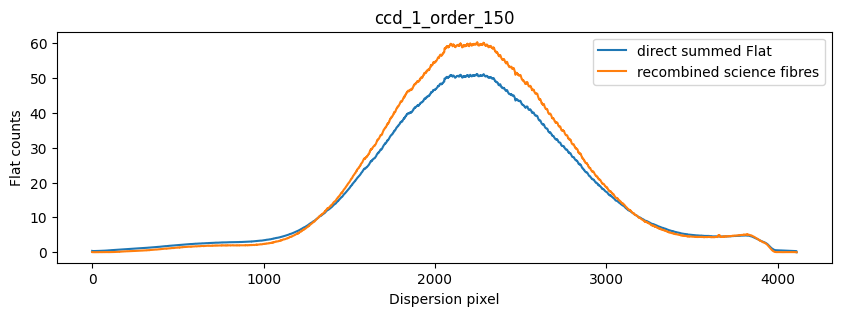

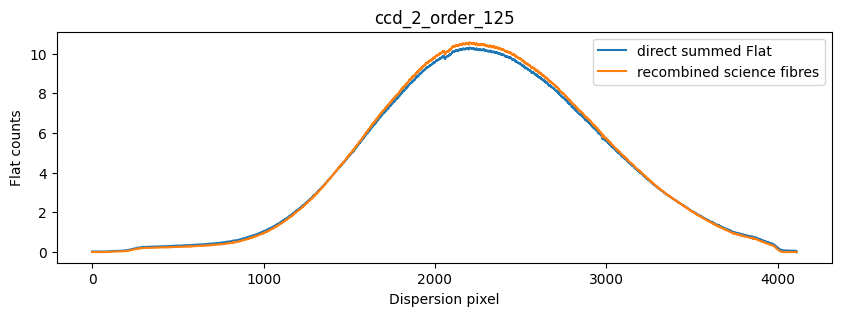

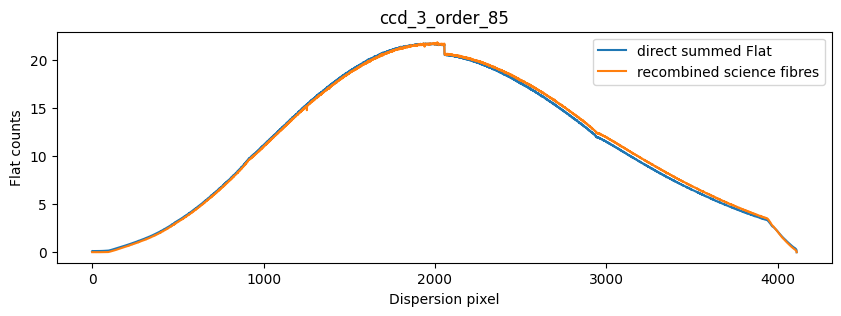

In [14]:
if config.extraction_mode == "fibre":
    for name in ['ccd_1_order_150', 'ccd_2_order_125', 'ccd_3_order_85']:
        product = flat_calibrations[name]
        geometry = fibre_geometry[name]
        science_components = {str(f) for f in constants.SCIENCE_FIBRES}

        science_idx = np.array([i for i, component in enumerate(geometry.components) if str(component) in science_components], dtype=int)
        recombined = np.nansum(product.fibre_flat[:, science_idx], axis=1)
        scale = np.nanmedian(product.summed_flat / recombined)

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(product.summed_flat, label="direct summed Flat")
        ax.plot(recombined * scale, label="recombined science fibres")
        ax.set(title=name, xlabel="Dispersion pixel", ylabel="Flat counts")
        # ax.set_ylim(-1,3)
        ax.legend()
        plt.show()


## 7. Extract calibration spectra in detector coordinates

The same fixed `OrderGeometry` is used for SimTh, SimLC and summed FibTh extraction. Fibre mode additionally extracts the 19 science-fibre FibTh spectra using the fixed `FibreGeometry`. These spectra are deliberately left in detector-pixel coordinates for the next wavelength-calibration stage.


In [23]:
import importlib
importlib.reload(extraction)

<module 'velocereduction.extraction' from '/Users/buder/velocereduction/velocereduction/extraction.py'>

In [24]:
calibration_exposures = extraction.extract_calibration_exposures(
    reduction_input, order_geometry, fibre_geometry, config
)
calibration_files = extraction.save_calibration_exposures(
    calibration_exposures, paths.calibrations, config.night, overwrite=True
)
for filename in calibration_files:
    print(filename.relative_to(paths.root))


INFO     Extracting SimLC calibration products
INFO         -> Skipping SimLC_SimTh001: no members passed calibration QA
INFO         -> Skipping SimLC001: no members passed calibration QA
INFO         -> Skipping SimLC_run0078: no members passed calibration QA
INFO         -> Skipping SimLC_run0079: no members passed calibration QA
INFO         -> Skipping SimLC_run0080: no members passed calibration QA
INFO         -> Skipping SimLC_run0081: no members passed calibration QA
INFO         -> Skipping SimLC_run0082: no members passed calibration QA
INFO         -> Skipping SimLC_run0083: no members passed calibration QA
INFO         -> Skipping SimLC_run0084: no members passed calibration QA
INFO         -> Skipping SimLC_run0097: no members passed calibration QA
INFO         -> Skipping SimLC_run0098: no members passed calibration QA
INFO         -> Skipping SimLC_run0100: no members passed calibration QA
INFO         -> Skipping SimLC_run0103: no members passed calibration QA
INFO    

KeyboardInterrupt: 

## 8. Wavelength calibration

 Peak measurement and reference-line identification are source-specific (`thorium.py` and `simlc.py`) with `wavelength.py` using the identified line tables to fit the wavelength models.

### 8.1 Reference inputs and bootstrap wavelength solution

The bootstrap solution is used only to identify which laboratory/comb line corresponds to a measured peak. It is not the final nightly wavelength solution. Once the reference night has been validated, `wavelength_static_001122_ccd*.fits` should become the normal bootstrap for subsequent nights.

In [ ]:
Y_BOUNDS = (0.0, 4111.0)
ORDER_BOUNDS = {
    "1": (138, 167),
    "2": (103, 140),
    "3": (65, 104),
}

# Original Murphy atlas + the editable Veloce-specific selection.
murphy_atlas_file = paths.reference_data / "thar_UVES_MM090311.dat"
veloce_atlas_file = paths.reference_data / "veloce_thorium_reference.fits"

if veloce_atlas_file.exists():
    thorium_atlas = thorium.read_veloce_thorium_atlas(veloce_atlas_file)
    print(f"Using curated Veloce Th atlas: {veloce_atlas_file.name}")
else:
    thorium_atlas = thorium.load_murphy_thorium_atlas(murphy_atlas_file)
    print("WARNING: curated Veloce Th atlas not found; using all Murphy Th lines.")

bootstrap_solution = {}
for ccd in ("1", "2", "3"):
    final_reference = (
        paths.reference_data
        / f"wavelength_static_{config.reference_night}_ccd{ccd}.fits"
    )
    legacy_bootstrap = (
        paths.reference_data
        / f"wavelength_bootstrap_{config.reference_night}_ccd{ccd}.fits"
    )
    filename = legacy_bootstrap if legacy_bootstrap.exists() else final_reference
    if not filename.exists():
        raise FileNotFoundError(f"No bootstrap wavelength solution for CCD{ccd}: {filename}")
    bootstrap_solution[ccd], _ = wavelength.read_wavelength_solution_fits(filename)


def detector_shift_y(ccd):
    return detector.detector_shift(detector_shifts, ccd)[1]


def summed_arrays(exposure):
    # extraction stores (4112, n_orders); calibration fitting uses
    # (n_orders, 4112).
    return exposure.summed.flux.T, exposure.summed.variance.T

### 8.2 Calibration-line measurements

#### 8.2.1 FibTh and SimTh

Both thorium sources use the same line measurement/identification machinery. The returned table contains order, measured dispersion position and uncertainty, reference wavelength, quality flags, and detector-space FWHM.

In [ ]:
thorium_line_sets = {
    source: {ccd: [] for ccd in ("1", "2", "3")}
    for source in ("FibTh", "SimTh")
}

# th_to_run = ['FibTh','SimTh']
th_to_run = ['FibTh']

for source in th_to_run:
    for ccd in ("1", "2", "3"):
        for exposure_index, exposure in enumerate(calibration_exposures[source][ccd]):
            filename = (
                paths.calibrations
                / f"{source.lower()}_lines_{config.night}_run{int(exposure.run):04d}_ccd{ccd}.fits"
            )

            if filename.exists() and not config.overwrite:
                try:
                    result = calibration.read_calibration_line_fits(filename)
                    print(f"Read existing {source} line fit: {filename.name}")
                except Exception as error:
                    print(f"Could not read {filename.name} ({error}); remeasuring")
                    result = None
            else:
                result = None

            if result is None:
                counts, variance = summed_arrays(exposure)
                result = thorium.measure_thorium_lines(
                    counts,
                    exposure.orders,
                    thorium_atlas,
                    variance=variance,
                    source=source,
                    ccd=ccd,
                    exposure_index=exposure_index,
                    mjd_mid=exposure.mjd_mid,
                    reference_wavelength_function=bootstrap_solution[ccd].wavelength,
                    detector_shift_y=detector_shift_y(ccd),
                    y_bounds=Y_BOUNDS,
                    minimum_reference_intensity=1.5,
                    diagnostics=config.diagnostics,
                    diagnostic_dir=paths.figures / "calibration",
                    log_level=config.log_level,
                )
                calibration.write_calibration_line_fits(result, filename, overwrite=True)

            thorium_line_sets[source][ccd].append(result)
            n_used = np.count_nonzero(result.lines["used_for_wavelength_fit"])
            print(
                f"{source} CCD{ccd} run {exposure.run}: "
                f"{n_used}/{len(result.lines)} identified lines retained"
            )


#### 8.2.2 SimLC

The laser-frequence comb (LC) provides ~10 times more and well-separated emission peaks with precise peaks for a more precise wavelength solution.  
Here we extract the centroids of these peaks across CCD2 and CCD3:
- First we identify all peaks and fit an integrated Gaussian to extract an initial line-spread-function (LSF) with a specific full-width-half-maximum (FWHM).
- We then parametrise this shape as a smoothly varying LSF.
- We then optimise the centroids with the optimised lsf_shape (with a Moffat shape as default).

In [ ]:
simlc_measurements = {}
source = "SimLC"

for ccd in ('2', '3'):
    for exposure_index, exposure in enumerate(calibration_exposures[source][ccd]):

        filename = (
            paths.calibrations
            / f"simlc_lines_{config.night}_ccd{ccd}.fits"
        )

        if filename.exists() and not config.overwrite:
            try:
                result = calibration.read_calibration_line_fits(filename)
                print(f"Read existing {source} line fit: {filename.name}")
                simlc_measurements[ccd] = result
            except Exception as error:
                print(f"Could not read {filename.name} ({error}); remeasuring")
                result = None
        else:
            result = None

        if result is None:
            simlc_measurements[ccd] = simlc.measure_simlc_lines(
                calibration_exposures[source][ccd][exposure_index],
                paths.reference_data
                / f"wavelength_static_{config.reference_night}_ccd{ccd}.fits",
                lsf_shape="moffat",
                minimum_snr=15,
                diagnostics=config.diagnostics,
                diagnostic_dir=paths.figures,
                output_filename=paths.calibrations
                / f"simlc_lines_{config.night}_ccd{ccd}.fits",
                overwrite=config.overwrite,
                log_level=config.log_level,
            )

### 8.3 Static summed wavelength solution

For the first static solution, choose the FibTh exposure closest to the median calibration time and fit the global $m\lambda(y,m)$ surface. The Legendre degrees are selected by spatially blocked cross-validation rather than from the training residuals.

This is intentionally the **FibTh-only baseline**. The next implementation step is to transform SimLC positions onto the summed-science coordinate and replace the FibTh constraints order-by-order where reliable SimLC coverage exists on CCDs 2 and 3.

In [ ]:
all_calibration_mjds = [
    exposure.mjd_mid
    for source in calibration_exposures.values()
    for ccd_exposures in source.values()
    for exposure in ccd_exposures
    if np.isfinite(exposure.mjd_mid)
]
t0 = float(np.median(all_calibration_mjds))
print(f"Wavelength reference epoch: MJD {t0:.8f}")

static_wavelength = {}
static_fitted_lines = {}
static_validation = {}
static_reference_exposure = {}
static_reference_index = 0

preliminary_solution = {}

for ccd in ("1", "2", "3"):

    for calibration_type in ['FibTh']:#,'SimLC']:#,'FibTh+SimLC']:

        if calibration_type == 'FibTh':

            # FibTh Only
            
            static_reference_exposure[ccd] = calibration_exposures["FibTh"][ccd][static_reference_index]
            fit_input = thorium_line_sets["FibTh"][ccd][static_reference_index].lines
            
        elif calibration_type == 'SimLC':

            if ccd == '1':
                print(f"CCD{ccd}: No SimLC measurements available; skipping")
                continue
            
            # SimLC Only
            fit_input = simlc_measurements[ccd].lines

        elif calibration_type == 'FibTh+SimLC':

            if ccd == '1':
                print(f"CCD{ccd}: No SimLC measurements available; skipping")
                continue

            fit_input, transfer, transferred_lc = wavelength.build_hybrid_static_peak_table(
                thorium_line_sets["FibTh"][ccd][static_reference_index].lines,
                simlc_measurements[ccd].lines,
                preliminary_solution[ccd],
            )

        fit, fitted_lines, validation, chosen = (
            wavelength.fit_validated_wavelength_from_peak_table(
            fit_input,
            y_degrees=[7],
            order_degrees=[5],
            n_folds=5,
            y_blocks=10,
            )
        )

        preliminary_solution[ccd] = fit.solution
        
        static_wavelength[ccd] = fit.solution
        static_fitted_lines[ccd] = fitted_lines
        static_validation[ccd] = validation

        # validation.write(
        #     paths.calibrations / f"wavelength_surface_cv_{calibration_type}_{config.night}_ccd{ccd}.fits",
        #     overwrite=True,
        # )
        # diagnostics.print_wavelength_degree_summary(validation, chosen, ccd=ccd)
        # if config.diagnostics != "none":
        #     diagnostics.save_wavelength_degree_diagnostics(
        #         validation,
        #         chosen,
        #         paths.figures / f"wavelength_surface_cv_{calibration_type}_{config.night}_ccd{ccd}.png",
        #         calibration_type=calibration_type,
        #         ccd=ccd,
        #         diagnostics=config.diagnostics,
        #     )
        wavelength.write_wavelength_fit_fits(
            fit,
            fitted_lines,
            paths.calibrations / f"wavelength_static_{calibration_type}_{config.night}_ccd{ccd}.fits",
            calibration_type=calibration_type,
            ccd=ccd,
            mjd_mid=static_reference_exposure[ccd].mjd_mid,
            # source_peak_file=(
            #     f"fibth_lines_{config.night}_run{int(exposure.run):04d}_ccd{ccd}.fits"
            # ),
            overwrite=True,
        )

        diagnostics.print_wavelength_fit_summary(
            fit, fitted_lines, calibration_type=calibration_type, ccd=ccd,
        )
        if config.diagnostics != "none":
            diagnostics.save_wavelength_diagnostics(
                fit,
                fitted_lines,
                paths.figures / f"wavelength_static_{calibration_type}_{config.night}_ccd{ccd}.png",
                calibration_type=calibration_type,
                ccd=ccd,
                diagnostics=config.diagnostics,
            )

### 8.4 Joint fibre displacement reference

In fibre mode the first FibTh exposure is used to load or construct the joint rank-2 fibre displacement model. Per-fibre line measurement, matching, fitting, reference FITS I/O, and QA plotting are handled inside `wavelength.ensure_fibre_displacement_model()`.


In [ ]:
fibre_displacement_model = None

if config.extraction_mode == "fibre":
    fibre_displacement_model, matched_fibre_lines = wavelength.ensure_fibre_displacement_model(
        config=config,
        paths=paths,
        calibration_exposures=calibration_exposures,
        summed_fibth_line_sets={
            ccd: thorium_line_sets["FibTh"][ccd][static_reference_index]
            for ccd in ("1", "2", "3")
        },
        static_wavelength=static_wavelength,
        thorium_atlas=thorium_atlas,
        static_fibth_reference_index=static_reference_index,
    )

    print(
        "Fibre displacement reference: "
        f"{fibre_displacement_model.reference_night or config.reference_night}; "
        f"rank={fibre_displacement_model.rank}, degree={fibre_displacement_model.degree}"
    )


In [ ]:
if config.extraction_mode == "fibre" and config.diagnostics != "none":
    print("Fibre displacement before/after QA written to", paths.figures / "calibration")


### 8.5 Temporal wavelength corrections

All SimTh and SimLC exposures have already been reduced to homogeneous line tables above. The forthcoming temporal model will compare each source against its own reference epoch so that the fixed SimTh/SimLC fibre offset is not confused with temporal drift.

In [ ]:
time_shift_model = {ccd: None for ccd in ("1", "2", "3")}
time_shift_qa = {}
time_shift_series = {}
wavelength_model = {}

for ccd in static_wavelength:
    lc_sets = simlc_measurements.get(ccd, [])
    th_sets = thorium_line_sets["SimTh"].get(ccd, [])

    try:
        time_model, qa, all_series = wavelength.fit_time_corrections(
            static_solution=static_wavelength[ccd],
            simlc_line_sets=lc_sets,
            simth_line_sets=th_sets,
            reference_mjd=t0,
            y_degree=2,
            order_degree=1,
            preferred_source="SimLC",
        )
        time_shift_model[ccd] = time_model
        time_shift_qa[ccd] = qa
        time_shift_series[ccd] = all_series
        qa.write(
            paths.calibrations / f"wavelength_time_qa_{config.night}_ccd{ccd}.fits",
            overwrite=True,
        )
        print(
            f"CCD{ccd}: temporal source={time_model.source}, "
            f"N={len(time_model.mjd)}, reference MJD={time_model.reference_mjd:.8f}"
        )
    except RuntimeError as error:
        print(f"CCD{ccd}: no temporal correction ({error})")

    wavelength_model[ccd] = wavelength.WavelengthCalibration(
        static=static_wavelength[ccd],
        fibre=fibre_displacement_model,
        time=time_shift_model.get(ccd),
        ccd=ccd,
    )
    wavelength.write_wavelength_model_fits(
        wavelength_model[ccd],
        paths.calibrations / f"wavelength_model_{config.night}_ccd{ccd}.fits",
        ccd=ccd,
        reference_mjd=t0,
        overwrite=True,
    )


### 8.6 Compact QA / usage check

In [ ]:
for ccd, model in wavelength_model.items():
    m0 = int(np.round(np.mean(ORDER_BOUNDS[ccd])))
    y0 = 0.5 * sum(Y_BOUNDS)
    message = [f"CCD{ccd}: lambda({y0:.1f}, m={m0})={model.static.wavelength(y0, m0):.6f} nm"]
    if model.time is not None:
        drift = [float(model.time.shift(y0, m0, t)) for t in model.time.mjd]
        message.append(
            f"{model.time.source} drift range=[{np.min(drift):+.4f}, {np.max(drift):+.4f}] pix"
        )
    print("; ".join(message))

# Example for a science/fibre spectrum:
# y = np.arange(4112, dtype=float)
# wave_nm = wavelength_model[ccd].wavelength(
#     y, order, fibre=int(fibre_name), mjd=science_mjd_mid
# )

### 9 Resolution profile

The peak tables persist `fwhm_pixel` and `fwhm_uncertainty_pixel`. Once the final wavelength model is fixed, the local wavelength FWHM and resolving power can be derived from

$$
\Delta\lambda_{\rm FWHM}
=
\left|\frac{d\lambda}{dy}\right|
{\rm FWHM}_{\rm pix},
\qquad
\mathcal{R}
=
\frac{\lambda}{\Delta\lambda_{\rm FWHM}}.
$$

The smooth $\mathcal{R}(y,m)$ model should therefore be fitted after the wavelength solution rather than stored as a primary line-fit quantity.

In [ ]:
# resolution_measurements = {}

# for ccd, lines in static_fitted_lines.items():
#     used = np.asarray(lines["used_for_wavelength_fit"], bool)
#     y = np.asarray(lines["y"], float)
#     order = np.asarray(lines["order"], int)
#     fwhm_pixel = np.asarray(lines["fwhm_pixel"], float)

#     wavelength_nm = static_wavelength[ccd].wavelength(y, order)
#     dispersion_nm_per_pixel = np.abs(
#         static_wavelength[ccd].dispersion(y, order)
#     )
#     delta_lambda_nm = dispersion_nm_per_pixel * fwhm_pixel
#     resolving_power = np.divide(
#         wavelength_nm,
#         delta_lambda_nm,
#         out=np.full_like(wavelength_nm, np.nan),
#         where=np.isfinite(delta_lambda_nm) & (delta_lambda_nm > 0),
#     )

#     resolution_measurements[ccd] = Table(
#         {
#             "order": order[used],
#             "y": y[used],
#             "wavelength_nm": wavelength_nm[used],
#             "fwhm_pixel": fwhm_pixel[used],
#             "resolving_power": resolving_power[used],
#         }
#     )

#     display(resolution_measurements[ccd][:5])

# # NEXT: fit a smooth resolution profile in (y, m).

## 9. Science extraction


In [ ]:
# This needs to be updated later, once we have all the calibration products, to extract and calibrate thescience exposures

# science_exposures = science.extract_science_exposures(
#     reduction_input, nightly_tramlines, flat_products,
#     wavelength_model, config, paths
# )
# print(f"{len(science_exposures)} science CCD exposures")

# if science_exposures:
#     exposure = science_exposures[0]
#     order = exposure.orders[len(exposure.orders) // 2]
#     plt.figure(figsize=(10, 3))
#     plt.plot(order.barycentric_wavelength_nm, order.flux)
#     plt.xlabel("Barycentric wavelength / nm")
#     plt.ylabel("Flux")
#     plt.title(f"{exposure.object_name} — CCD{exposure.ccd}, order {order.order}")
#     plt.show()


## One-call equivalent


In [ ]:
# from velocereduction import pipeline
# state = pipeline.reduce_night(config, version=__version__)
